### Setup & imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib


### Load the FRAGTrack CSV

In [5]:
data_path = pathlib.Path().resolve() / "fragtrack" / "HS09 (Metric) - Oct-2025.csv"

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(df.shape)
df.head()


Loading data from: C:\GitHubRepositories\mining_sim\backend\data\fragtrack\HS09 (Metric) - Oct-2025.csv
(6415, 33)


,TimeStamp UTC,TimeStamp Site TZ,P20 RR (mm),P20 SWB (mm),P50 RR (mm),P50 SWB (mm),P80 RR (mm),P80 SWB (mm),Top Size RR (mm),Top Size SWB (mm),...,Instantaeous Mass (t/hr),Latitude,Longitude,Altitude (m),Easting (m),Northing (m),Elevation (m),IsDay,IsGeoreferenced,pattern_id
0,2025-10-02 00:00:00,2025-01-27T11:20:54.000Z,53.322052,83.983344,108.855247,110.828521,200.317104,151.719354,415.147591,399.934011,...,0.0,0.0,0.0,0.0,1.016644e+07,-209711.502728,0.0,True,False,p_004_005
1,2025-10-02 00:02:05,2025-01-27T11:22:59.000Z,49.182612,74.032878,95.001462,92.471593,159.518528,126.601576,265.230590,233.926332,...,0.0,0.0,0.0,0.0,9.921226e+06,-204686.207817,0.0,True,False,p_004_005
2,2025-10-02 00:03:19,2025-01-27T11:24:13.000Z,25.344797,34.464802,49.106803,40.858252,70.963518,56.358692,157.137866,150.331990,...,0.0,0.0,0.0,0.0,1.076932e+07,-212790.098204,0.0,True,False,p_000_000
3,2025-10-02 00:04:19,2025-01-27T11:25:13.000Z,36.888685,33.980555,79.839564,82.587817,143.645517,145.044108,292.501699,295.646637,...,0.0,0.0,0.0,0.0,1.052365e+07,-223871.528622,0.0,True,False,p_004_006
4,2025-10-02 00:05:19,2025-01-27T11:26:13.000Z,32.091490,33.385094,61.512810,57.293986,94.951300,94.625985,247.516216,246.832443,...,0.0,0.0,0.0,0.0,1.092382e+07,-195901.540356,0.0,True,False,p_000_000


### Basic hygiene & filtering

Before extracting coefficients, remove pathological rows:

In [6]:
cols_required = [
    "P20 RR (mm)", "P50 RR (mm)", "P80 RR (mm)",
    "RR Xc (mm)", "RR n",
    "SWB b", "SWB x50 (mm)", "SWB xMax (mm)"
]

df_clean = df[cols_required].replace([np.inf, -np.inf], np.nan).dropna()

df_clean.describe()


,P20 RR (mm),P50 RR (mm),P80 RR (mm),RR Xc (mm),RR n,SWB b,SWB x50 (mm),SWB xMax (mm)
count,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000,6415.000000
mean,28.293703,70.654551,143.477519,95.912497,1.223965,5.150790,72.059877,822.909253
std,15.710251,32.365385,62.245103,42.262425,0.274619,3.006179,33.388254,564.870475
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.349263,12.846134,134.496546
25%,16.778276,47.354380,97.828297,65.089337,1.035335,2.650075,47.376543,401.456680
50%,25.197215,64.816684,133.389174,89.287712,1.209910,4.333609,65.288631,621.893319
75%,36.346636,88.560420,178.184678,120.069717,1.406544,7.048084,89.856658,1097.866288
max,109.558786,230.967747,556.330918,303.125554,2.192738,19.805566,230.442236,3443.420435


### PSD visualisation (sanity check)

A simple P-curve overview already tells you whether fragmentation is stable enough to justify a single parameter set.

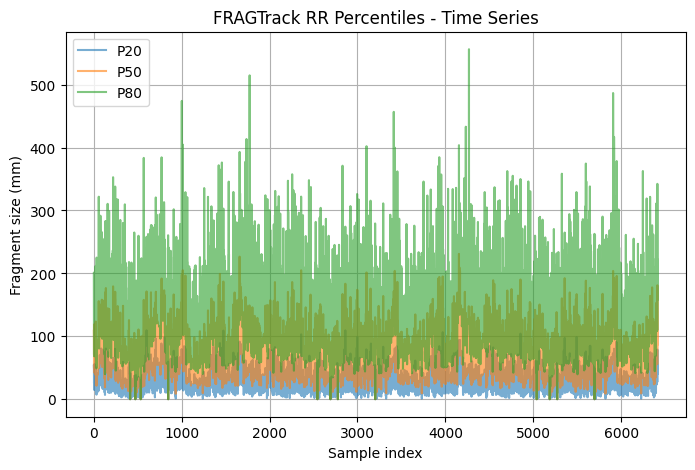

In [7]:
plt.figure(figsize=(8,5))

plt.plot(df_clean["P20 RR (mm)"], label="P20", alpha=0.6)
plt.plot(df_clean["P50 RR (mm)"], label="P50", alpha=0.6)
plt.plot(df_clean["P80 RR (mm)"], label="P80", alpha=0.6)

plt.ylabel("Fragment size (mm)")
plt.xlabel("Sample index")
plt.title("FRAGTrack RR Percentiles - Time Series")
plt.legend()
plt.grid(True)
plt.show()


### Extract RR (Rosin-Rammler) coefficients

FRAGTrack has already fitted RR distributions per sample. What you want for your model is a robust central tendency, not a single blast fit.

In [8]:
rr_summary = {
    "Xc_mm_median": df_clean["RR Xc (mm)"].median(),
    "Xc_mm_p25": df_clean["RR Xc (mm)"].quantile(0.25),
    "Xc_mm_p75": df_clean["RR Xc (mm)"].quantile(0.75),
    "n_median": df_clean["RR n"].median(),
    "n_p25": df_clean["RR n"].quantile(0.25),
    "n_p75": df_clean["RR n"].quantile(0.75),
}

rr_summary


{'Xc_mm_median': np.float64(89.28771230062294),
 'Xc_mm_p25': np.float64(65.08933705475711),
 'Xc_mm_p75': np.float64(120.06971686856122),
 'n_median': np.float64(1.2099096583546294),
 'n_p25': np.float64(1.0353353464052808),
 'n_p75': np.float64(1.40654382547162)}

### Extract Swebrec coefficients (recommended primary model)

Since your YAML already references SWB parameters, these are the most valuable:

In [9]:
swb_summary = {
    "b_median": df_clean["SWB b"].median(),
    "b_p25": df_clean["SWB b"].quantile(0.25),
    "b_p75": df_clean["SWB b"].quantile(0.75),
    "x50_mm_median": df_clean["SWB x50 (mm)"].median(),
    "xMax_mm_median": df_clean["SWB xMax (mm)"].median(),
}

swb_summary


{'b_median': np.float64(4.333608898657093),
 'b_p25': np.float64(2.6500746857750572),
 'b_p75': np.float64(7.048084027235033),
 'x50_mm_median': np.float64(65.28863086343165),
 'xMax_mm_median': np.float64(621.8933185466766)}

### Reconstruct a representative PSD

Using median SWB parameters, you can reconstruct a site-average PSD:

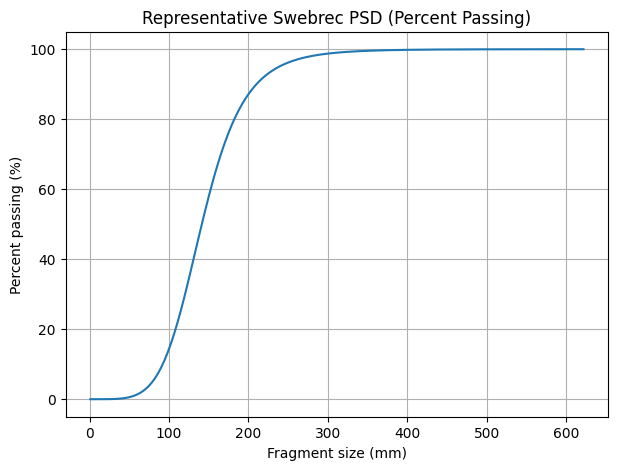

In [10]:
def swebrec_psd_passing(x, x50, x_max, b):
    retained = 1 / (1 + (x / x50)**b * np.exp(b * (x / x_max - 1)))
    return 1 - retained


x = np.linspace(1, swb_summary["xMax_mm_median"], 300)
y = swebrec_psd_passing(
    x,
    swb_summary["x50_mm_median"],
    swb_summary["xMax_mm_median"],
    swb_summary["b_median"]
)

plt.figure(figsize=(7,5))
plt.plot(x, y * 100)
plt.xlabel("Fragment size (mm)")
plt.ylabel("Percent passing (%)")
plt.title("Representative Swebrec PSD (Percent Passing)")
plt.grid(True)
plt.show()


In [11]:
import yaml
import copy
import pathlib

# --- Paths ---
config_path = pathlib.Path().resolve().parent / "config" / "config.yaml"
output_path = pathlib.Path().resolve().parent / "config" / "config_fragtrack_calibrated.yaml"

# --- Load existing config ---
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f) or {}

# Keep a copy in memory (for debugging / comparisons)
cfg_original = copy.deepcopy(cfg)

# --- Inject fragmentation baseline + calibration ---
cfg.setdefault("fragmentation", {})

# 1) Set a baseline RR distribution (robust summary from FRAGTrack)
cfg["fragmentation"].setdefault("distribution", {})
cfg["fragmentation"]["distribution"]["type"] = "rr"
cfg["fragmentation"]["distribution"]["params"] = {
    "xc_mm": {"p25": 65.1, "median": 89.3, "p75": 120.1},
    "n":     {"p25": 1.04, "median": 1.21, "p75": 1.41},
}

# 2) Store the FRAGTrack calibration payload (kept separate, non-breaking)
cfg["fragmentation"]["calibration"] = {
    "source": "fragtrack",
    "dataset": "HS09_Metric_Oct2025.csv",
    "fitted_models": {
        "swebrec": {
            "b":      {"p25": 2.65,  "median": 4.33,  "p75": 7.05},
            "x50_mm":  {"p25": 47.4,  "median": 65.3,  "p75": 89.9},
            "xMax_mm": {"p25": 401.5, "median": 621.9, "p75": 1097.9},
        }
    },
}

# --- Write a new config file ---
with open(output_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Wrote calibrated config: {output_path}")


Wrote calibrated config: C:\GitHubRepositories\mining_sim\backend\config\config_fragtrack_calibrated.yaml
